# 3. CSP implementation

## 1. import settings

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Path settings
import sys
sys.path.append('..')

# import basic lib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import scikit learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.linalg import eigh

# import mne
import mne

from src.preprocessing import preprocess_eeg_data, preprocess_subject_runs
from src.evaluation import evaluate_all_subjects
from src.csp import CSP
from src.pipeline import create_pipeline

## 1-1. initialization

In [2]:
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')

X, y = preprocess_eeg_data('../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Extracting EDF parameters from ../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and

## 2. CSP implementation

### 2-1 Testing

In [3]:
csp = CSP(n_components=4)

csp.fit(X, y)
features = csp.transform(X)

print(f"features shape: {features.shape}")
print(f"features:\n{features}")

features shape: (15, 4)
features:
[[-0.68235048 -0.70328842 -1.22403088 -1.34509647]
 [-1.20439421 -1.04784462 -0.65048185 -0.61287329]
 [-1.17917055 -1.21008777 -0.72457372 -1.00835293]
 [-0.79681601 -0.65778724 -1.39934531 -1.31771303]
 [ 0.2256632  -0.44387138 -1.15242102 -1.32749833]
 [-1.65044224 -1.1586325  -0.73063846 -0.97900788]
 [-1.27039192 -1.0728891  -0.4870976  -0.76752516]
 [-1.11988157 -0.73602954 -1.1544534  -1.52319848]
 [-1.20558244 -1.26069675  0.07185119 -0.40543677]
 [ 0.58619413  0.41215276 -1.12128597 -1.10980132]
 [-0.99641855 -0.82402241 -1.28106167 -1.10323892]
 [-1.24063878 -1.01932445 -0.13554216  0.00761602]
 [-1.3473835  -1.19673872 -0.43090887 -0.3238234 ]
 [-1.07222243 -0.52503551 -0.79678931 -0.93434628]
 [-1.22438155 -0.92939648 -0.29677478  0.39378554]]


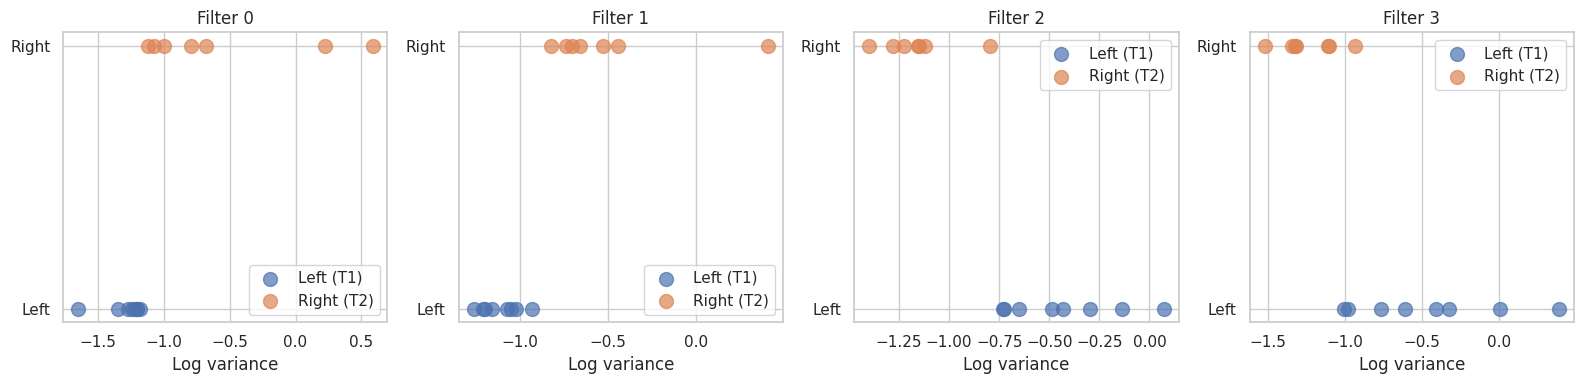

In [4]:
# visualization

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i in range(4):
	axes[i].scatter(features[y == 0, i], np.zeros(sum(y == 0)),
						label='Left (T1)', s=100, alpha=0.7)
	axes[i].scatter(features[y == 1, i], np.ones(sum(y == 1)),
						label='Right (T2)', s=100, alpha=0.7)
	axes[i].set_title(f'Filter {i}')
	axes[i].set_xlabel('Log variance')
	axes[i].set_yticks([0, 1], ['Left', 'Right'])
	axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
mne.set_log_level('WARNING')

raw_temp = mne.io.read_raw_edf(
	'../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf',
	preload=False
)
print([f"{i}: {ch}" for i, ch in enumerate(raw_temp.ch_names)])

ch_names = raw_temp.ch_names

c3_index = ch_names.index('C3..')
c4_index = ch_names.index('C4..')

print(f"C3 index: {c3_index}")
print(f"C4 index: {c4_index}")
print()
print(f"C3 weights: {csp.filters_[c3_index]}")
print(f"C4 weights: {csp.filters_[c4_index]}")

['0: Fc5.', '1: Fc3.', '2: Fc1.', '3: Fcz.', '4: Fc2.', '5: Fc4.', '6: Fc6.', '7: C5..', '8: C3..', '9: C1..', '10: Cz..', '11: C2..', '12: C4..', '13: C6..', '14: Cp5.', '15: Cp3.', '16: Cp1.', '17: Cpz.', '18: Cp2.', '19: Cp4.', '20: Cp6.', '21: Fp1.', '22: Fpz.', '23: Fp2.', '24: Af7.', '25: Af3.', '26: Afz.', '27: Af4.', '28: Af8.', '29: F7..', '30: F5..', '31: F3..', '32: F1..', '33: Fz..', '34: F2..', '35: F4..', '36: F6..', '37: F8..', '38: Ft7.', '39: Ft8.', '40: T7..', '41: T8..', '42: T9..', '43: T10.', '44: Tp7.', '45: Tp8.', '46: P7..', '47: P5..', '48: P3..', '49: P1..', '50: Pz..', '51: P2..', '52: P4..', '53: P6..', '54: P8..', '55: Po7.', '56: Po3.', '57: Poz.', '58: Po4.', '59: Po8.', '60: O1..', '61: Oz..', '62: O2..', '63: Iz..']
C3 index: 8
C4 index: 12

C3 weights: [14679.48186822 11116.06302579 37672.71384188 21020.83084588]
C4 weights: [-16081.66164142   6845.96177088  48060.31555467   4649.23109134]


## 3. CSP + LDA Pipeline Baseline Evaluation

This section evaluates the current pipeline using epoch-level cross-validation
on runs R03, R07 and R11.

This result is a baseline experiment and is not the final held-out run test evaluation.

In [ ]:
# set the pipeline
pipeline = create_pipeline()

results_test = evaluate_all_subjects(
	pipeline=pipeline,
	run_ids=[3, 7, 11],
	subject_range=range(1, 110)
)


Subject 1: mean accuracy = 0.556


/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Subject 2: mean accuracy = 0.648
Subject 3: mean accuracy = 0.622
Subject 4: mean accuracy = 0.800
Subject 5: mean accuracy = 0.556
Subject 6: mean accuracy = 0.489
Subject 7: mean accuracy = 1.000
Subject 8: mean accuracy = 0.689
Subject 9: mean accuracy = 0.578


/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Subject 10: mean accuracy = 0.657
Subject 11: mean accuracy = 0.600


...

Subject 21: mean accuracy = 0.560


/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, 

Subject 22: mean accuracy = 0.720
Subject 23: mean accuracy = 0.556
Subject 24: mean accuracy = 0.711
Subject 25: mean accuracy = 0.733
Subject 26: mean accuracy = 0.867
Subject 27: mean accuracy = 0.511
Subject 28: mean accuracy = 0.533
Subject 29: mean accuracy = 0.756
Subject 30: mean accuracy = 0.511
Subject 31: mean accuracy = 0.800
Subject 32: mean accuracy = 0.911
Subject 33: mean accuracy = 0.622
Subject 34: mean accuracy = 0.647
Subject 35: mean accuracy = 0.711
Subject 36: mean accuracy = 0.511
Subject 37: mean accuracy = 0.503
Subject 38: mean accuracy = 0.467
Subject 39: mean accuracy = 0.622
Subject 40: mean accuracy = 0.644
Subject 41: mean accuracy = 0.600
Subject 42: mean accuracy = 0.978
Subject 43: mean accuracy = 0.600
Subject 44: mean accuracy = 0.711
Subject 45: mean accuracy = 0.644
Subject 46: mean accuracy = 0.933
Subject 47: mean accuracy = 0.511
Subject 48: mean accuracy = 0.822
Subject 49: mean accuracy = 0.844
Subject 50: mean accuracy = 0.756
Subject 51: me

/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
/home/donghank/total-perspective-vortex/notebook/../src/preprocessing.py:15: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


Subject 100: mean accuracy = 0.611
Subject 101: mean accuracy = 0.556
Subject 102: mean accuracy = 0.744
Subject 103: mean accuracy = 0.533
Subject 104: mean accuracy = 0.711
Subject 105: mean accuracy = 0.778
Subject 106: mean accuracy = 0.489
Subject 107: mean accuracy = 0.467
Subject 108: mean accuracy = 0.644
Subject 109: mean accuracy = 0.578
=== Evaluation Result ===
subject evaluated: 109/109

mean:    0.6597
median:  0.6444
std: 0.1371
min:    0.4000
max:    1.0000

>= 60%: 70/109
>= 70%: 39/109
>= 80%: 17/109
